# 01 - EDA and Preprocessing

Explore the AMEX default labels and monthly customer statement data, then save a cleaned statement-level parquet for feature engineering.


In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

## Load Labels


In [35]:
data_labels = pd.read_csv('../data/raw/train_labels.csv')

In [36]:
print(f"Labels shape: {data_labels.shape}")
data_labels.head()

Labels shape: (458913, 2)


,customer_ID,target
0,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,0
1,00000fd6641609c6ece5454664794f0340ad84dddce9a2...,0
2,00001b22f846c82c51f6e3958ccd81970162bae8b007e8...,0
3,000041bdba6ecadd89a52d11886e8eaaec9325906c9723...,0
4,00007889e4fcd2614b6cbe7f8f3d2e5c728eca32d9eb8a...,0


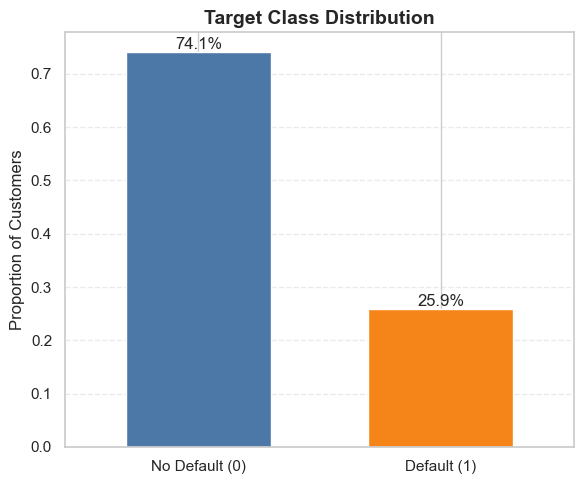

Note: The negative class has been subsampled to 5% in this competition dataset. Consequently, the Kaggle evaluation metric assigns a 20× weight to negative samples during scoring.


In [37]:
fig, ax = plt.subplots(figsize=(6, 5))

target_dist = (
    data_labels['target']
    .value_counts(normalize=True)
    .sort_index()
)

target_dist.plot(
    kind='bar',
    ax=ax,
    color=['#4C78A8', '#F58518'],
    width=0.6
)

ax.set_title('Target Class Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Proportion of Customers')
ax.set_xticklabels(['No Default (0)', 'Default (1)'], rotation=0)

# Add percentage labels
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1%}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

print("Note: The negative class has been subsampled to 5% in this competition dataset. Consequently, the Kaggle evaluation metric assigns a 20× weight to negative samples during scoring.")

## Balanced Customer Sample

Use a 50% sample from each target class before reading the large monthly statement file.


In [38]:
sample_0 = data_labels[data_labels['target'] == 0].sample(frac=0.50, random_state=42)
sample_1 = data_labels[data_labels['target'] == 1].sample(frac=0.50, random_state=42)

sampled_customers = pd.concat([sample_0, sample_1])['customer_ID']

In [39]:
print(f"Total customers: {len(data_labels)}")
print(f"Default rate: {data_labels['target'].mean():.2%}")
print(f"Sampled customers: {len(sampled_customers)}")

Total customers: 458913
Default rate: 25.89%
Sampled customers: 229456


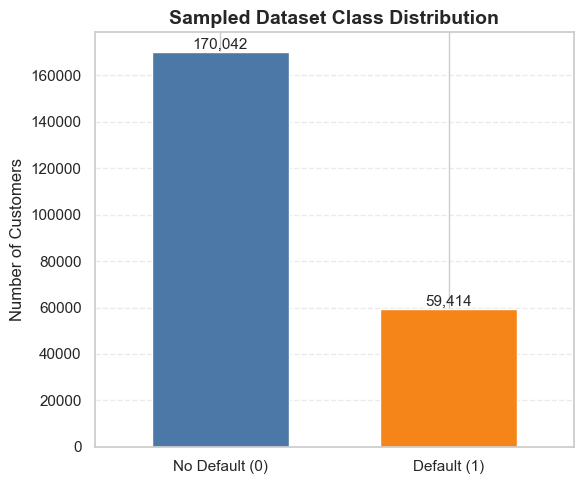

Note: To reduce computational cost while preserving the class distribution, a stratified sample containing 50% of both the default and non-default customers was used for feature engineering and model training.


In [40]:
fig, ax = plt.subplots(figsize=(6, 5))

sample_counts = (
    pd.concat([sample_0, sample_1])['target']
    .value_counts()
    .sort_index()
)

sample_counts.plot(
    kind='bar',
    ax=ax,
    color=['#4C78A8', '#F58518'],
    width=0.6
)

ax.set_title(
    'Sampled Dataset Class Distribution',
    fontsize=14,
    fontweight='bold'
)

ax.set_xlabel('')
ax.set_ylabel('Number of Customers', fontsize=12)

ax.set_xticklabels(
    ['No Default (0)', 'Default (1)'],
    rotation=0
)

# Add count labels
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height()):,}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=11
    )

ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

print(
    "Note: To reduce computational cost while preserving the class distribution, "
    "a stratified sample containing 50% of both the default and non-default customers "
    "was used for feature engineering and model training."
)

## Load Monthly Statements


In [41]:
chunks = []
for chunk in pd.read_csv('../data/raw/train_data.csv', chunksize=500000):
    chunk = chunk[chunk['customer_ID'].isin(sampled_customers)]
    chunks.append(chunk)

df = pd.concat(chunks)
print(f"Shape: {df.shape}")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

Shape: (2766578, 190)
Memory: 4.44 GB


## Missing Values


In [42]:
pd.set_option('display.max_rows', None)
missing_pct = df.isnull().mean() * 100
missing_pct = missing_pct.sort_values(ascending=False)
print(missing_pct)

D_87           99.924311
D_88           99.891021
D_108          99.476031
D_111          99.417042
D_110          99.417042
B_39           99.373233
D_73           98.973353
B_42           98.697091
D_134          96.499972
D_135          96.499972
D_136          96.499972
D_137          96.499972
D_138          96.499972
R_9            94.340264
B_29           93.123274
D_106          90.312292
D_132          90.290207
D_49           90.237145
R_26           89.015600
D_76           88.730735
D_66           88.661408
D_42           85.723699
D_142          82.983202
D_53           73.761521
D_82           73.352279
B_17           56.766048
D_50           56.713131
D_105          54.734188
D_56           54.047021
S_9            53.061508
D_77           45.436059
D_43           30.095302
S_27           25.407308
D_46           21.823748
S_7            18.536654
S_3            18.536654
D_62           13.695258
D_48           12.943210
D_61           10.803816
P_3             5.439463


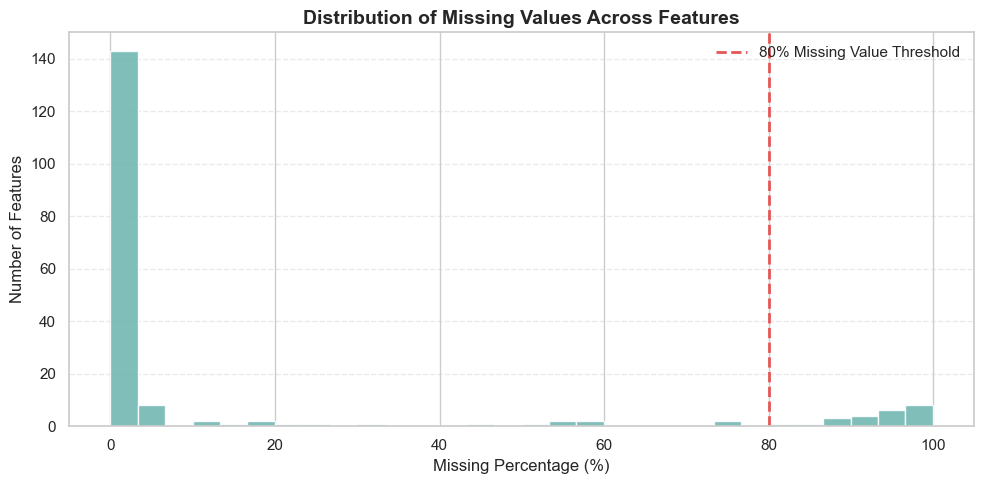

In [43]:
fig, ax = plt.subplots(figsize=(10, 5))

missing_pct.plot(
    kind='hist',
    bins=30,
    ax=ax,
    color='#72B7B2',
    edgecolor='white',
    alpha=0.9
)

ax.axvline(
    x=80,
    color='#E45756',
    linestyle='--',
    linewidth=2,
    label='80% Missing Value Threshold'
)

ax.set_title(
    'Distribution of Missing Values Across Features',
    fontsize=14,
    fontweight='bold'
)

ax.set_xlabel('Missing Percentage (%)', fontsize=12)
ax.set_ylabel('Number of Features', fontsize=12)

ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.legend(loc='upper right', frameon=False)

plt.tight_layout()
plt.show()

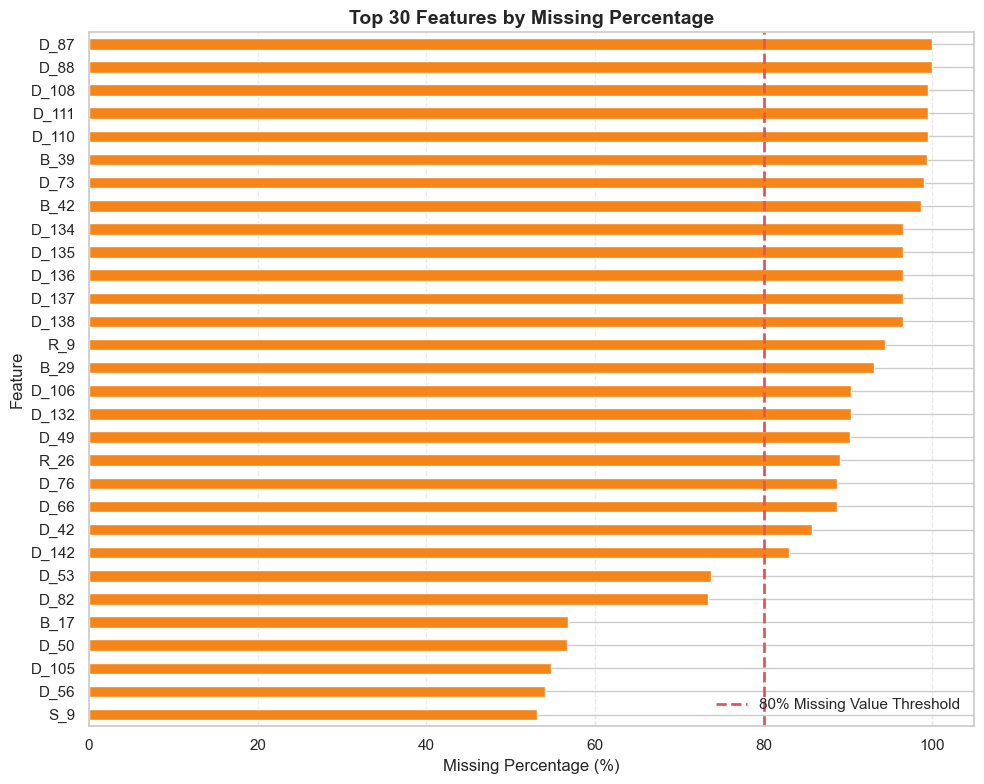

In [44]:
# Top 30 features with the highest missing percentage
top_missing = missing_pct.sort_values(ascending=False).head(30)
top_missing = top_missing.sort_values()

fig, ax = plt.subplots(figsize=(10, 8))

top_missing.plot(
    kind='barh',
    ax=ax,
    color='#F58518'
)

ax.axvline(
    x=80,
    color='#E45756',
    linestyle='--',
    linewidth=2,
    label='80% Missing Value Threshold'
)

ax.set_title(
    'Top 30 Features by Missing Percentage',
    fontsize=14,
    fontweight='bold'
)

ax.set_xlabel('Missing Percentage (%)', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)

ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.legend(loc='lower right', frameon=False)

plt.tight_layout()
plt.show()

In [45]:
cols_to_drop = missing_pct[missing_pct > 80].index.tolist()
print(f"Columns to drop: {len(cols_to_drop)}")
print(cols_to_drop)
df.drop(columns=cols_to_drop, inplace=True)

Columns to drop: 23
['D_87', 'D_88', 'D_108', 'D_111', 'D_110', 'B_39', 'D_73', 'B_42', 'D_134', 'D_135', 'D_136', 'D_137', 'D_138', 'R_9', 'B_29', 'D_106', 'D_132', 'D_49', 'R_26', 'D_76', 'D_66', 'D_42', 'D_142']


## Dtypes and Categorical Features


In [46]:
df['S_2'] = pd.to_datetime(df['S_2'])

cat_cols = [
    'D_63', 'D_64', 'B_30', 'B_38',
    'D_114', 'D_116', 'D_117',
    'D_120', 'D_126', 'D_68'
]

for col in cat_cols:
    df[col] = df[col].astype('category')

float_cols = df.select_dtypes(include='float64').columns
df[float_cols] = df[float_cols].astype('float32')

print(f"Memory after conversion: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")
print(df.dtypes.astype(str).value_counts())

print("Categorical columns:")
print(df.select_dtypes(include='category').columns)


Memory after conversion: 2.00 GB
float32           154
category           10
str                 1
datetime64[us]      1
int64               1
Name: count, dtype: int64
Categorical columns:
Index(['D_63', 'D_64', 'D_68', 'B_30', 'B_38', 'D_114', 'D_116', 'D_117',
       'D_120', 'D_126'],
      dtype='str')


## Longitudinal Structure


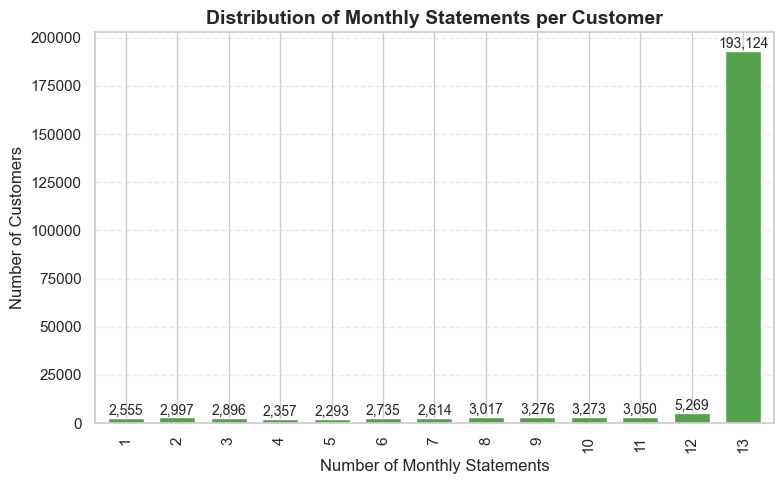

Summary Statistics


count    229456.000000
mean         12.057118
std           2.604692
min           1.000000
25%          13.000000
50%          13.000000
75%          13.000000
max          13.000000
dtype: float64


Observation: Most customers have approximately 13 monthly statements, providing sufficient historical information for customer-level feature engineering such as last-value, lag, rolling-window, and difference features.


In [48]:
fig, ax = plt.subplots(figsize=(8, 5))

statements_per_customer = df.groupby('customer_ID').size()
statement_counts = statements_per_customer.value_counts().sort_index()

statement_counts.plot(
    kind='bar',
    ax=ax,
    color='#54A24B',
    width=0.7
)

ax.set_title(
    'Distribution of Monthly Statements per Customer',
    fontsize=14,
    fontweight='bold'
)

ax.set_xlabel('Number of Monthly Statements', fontsize=12)
ax.set_ylabel('Number of Customers', fontsize=12)

# Add count labels
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height()):,}',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

print("Summary Statistics")
display(statements_per_customer.describe())

print(
    "\nObservation: Most customers have approximately 13 monthly statements, "
    "providing sufficient historical information for customer-level feature engineering "
    "such as last-value, lag, rolling-window, and difference features."
)

## Categorical Feature Checks


In [52]:
cat_summary = pd.DataFrame({
    "Feature": cat_cols,
    "Unique Values": [df[col].nunique(dropna=False) for col in cat_cols],
    "Missing (%)": [df[col].isna().mean() * 100 for col in cat_cols]
})

cat_summary

,Feature,Unique Values,Missing (%)
0,D_63,6,0.000000
1,D_64,5,3.925355
2,B_30,4,0.037411
3,B_38,8,0.037411
4,D_114,3,3.190331
5,D_116,3,3.190331
6,D_117,8,3.190331
7,D_120,3,3.190331
8,D_126,4,2.109429
9,D_68,8,3.907607


### Observation

- The dataset contains **10 categorical features**, each with **3–8 unique categories**.
- Missing values are low across all categorical features (less than **4%**).
- Missing values were retained, as LightGBM and XGBoost natively handle missing values during training.

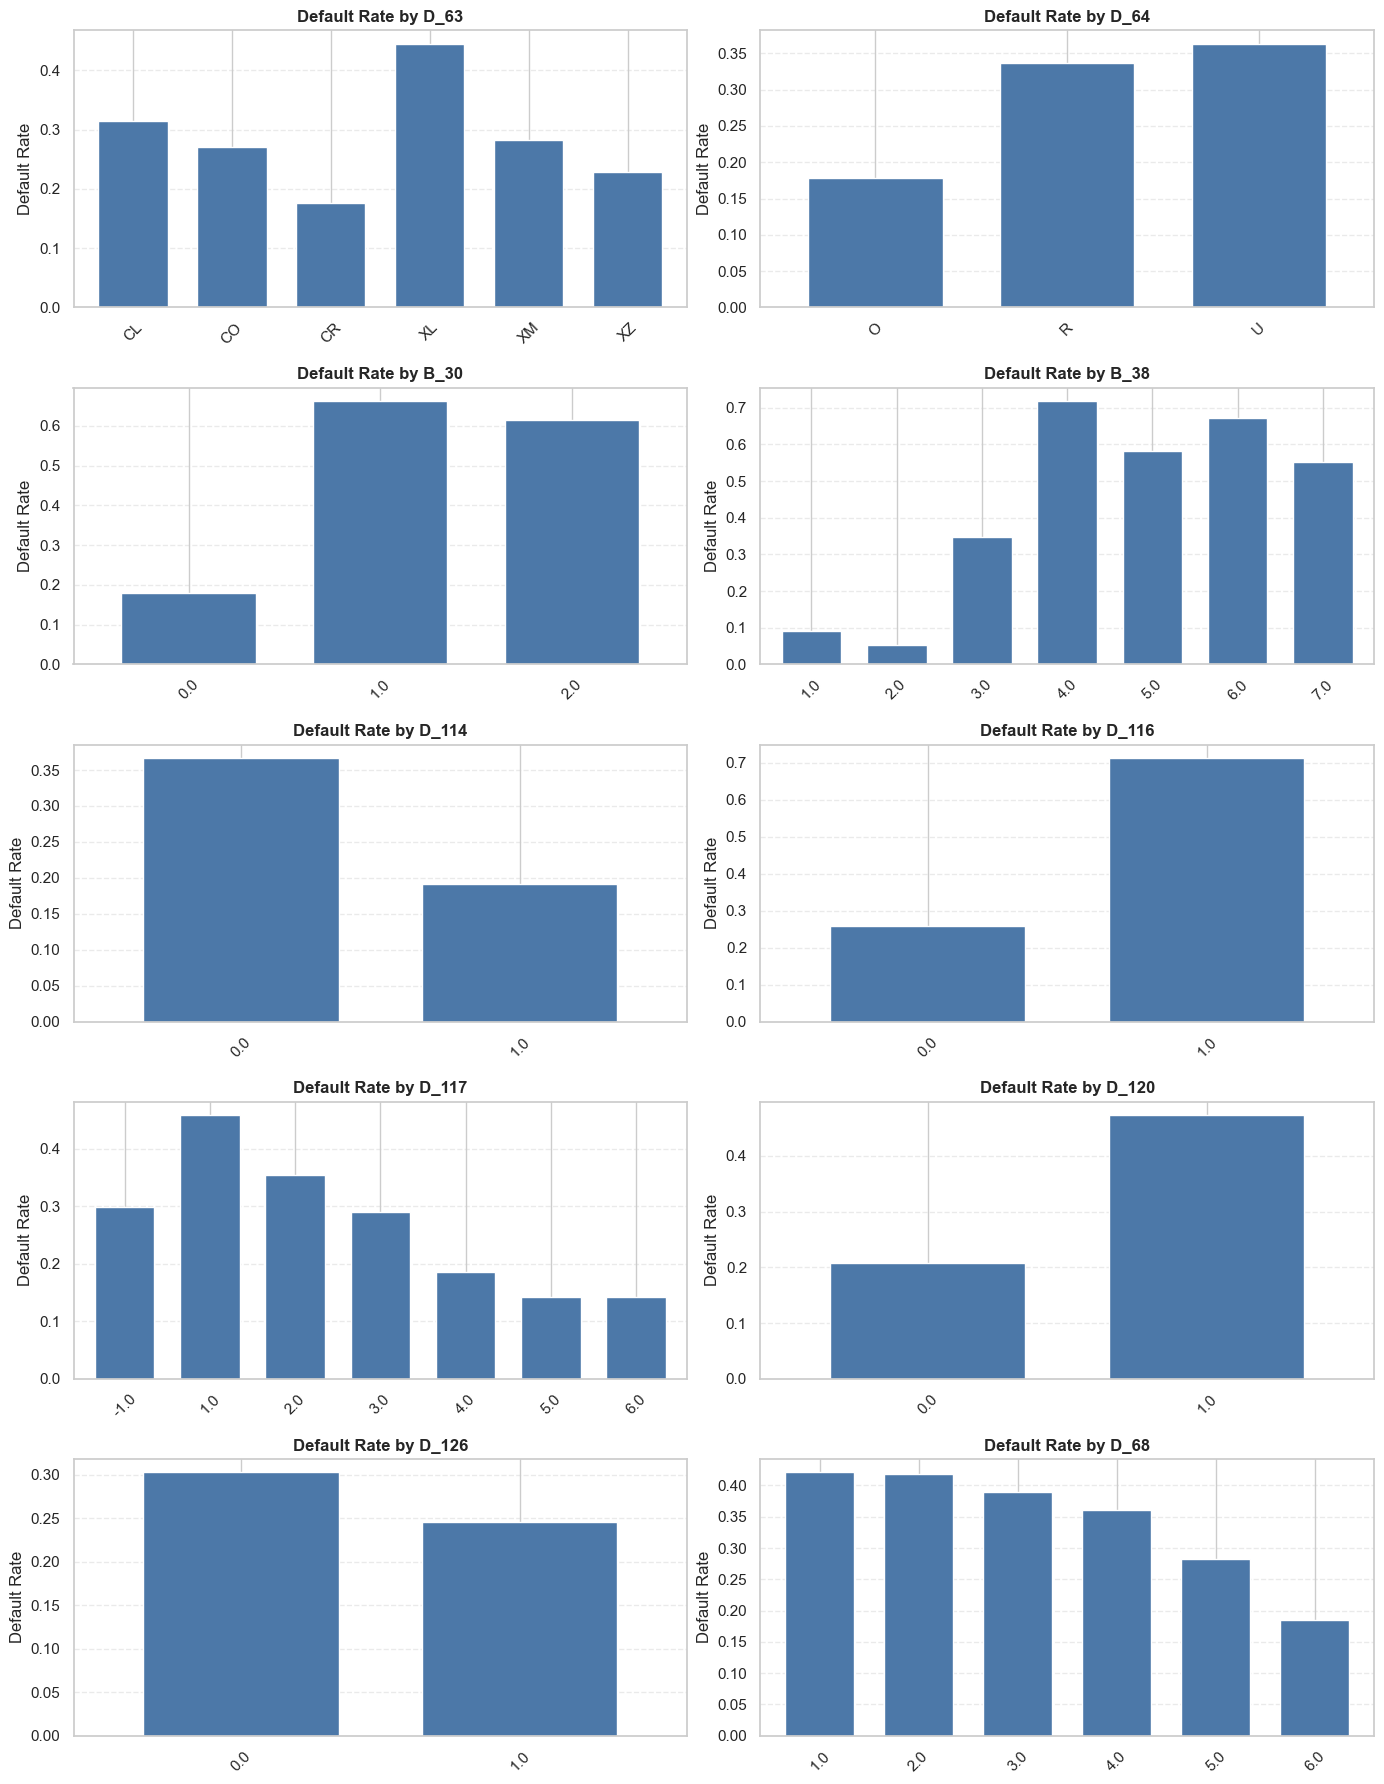

In [56]:
# Use the latest statement for each customer
last_df = (
    df.sort_values(["customer_ID", "S_2"])
      .groupby("customer_ID", as_index=False)
      .tail(1)
      .merge(data_labels[["customer_ID", "target"]], on="customer_ID", how="left")
)

fig, axes = plt.subplots(5, 2, figsize=(14, 18))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    default_rate = (
        last_df.groupby(col, observed=True)["target"]
        .mean()
        .sort_index()
    )

    default_rate.plot(
        kind="bar",
        ax=ax,
        color="#4C78A8",
        width=0.7
    )

    ax.set_title(
        f"Default Rate by {col}",
        fontsize=12,
        fontweight="bold"
    )
    ax.set_xlabel("")
    ax.set_ylabel("Default Rate")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

# Remove any unused subplots
for ax in axes[len(cat_cols):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

### Observation

- Several categorical features exhibit substantial variation in default rates across categories.
- Features such as **B_30**, **B_38**, **D_64**, and **D_68** demonstrate clear separation between low-risk and high-risk customer groups.
- These findings suggest that categorical attributes contain meaningful predictive information and were retained for customer-level feature engineering.

## Numeric Feature Checks


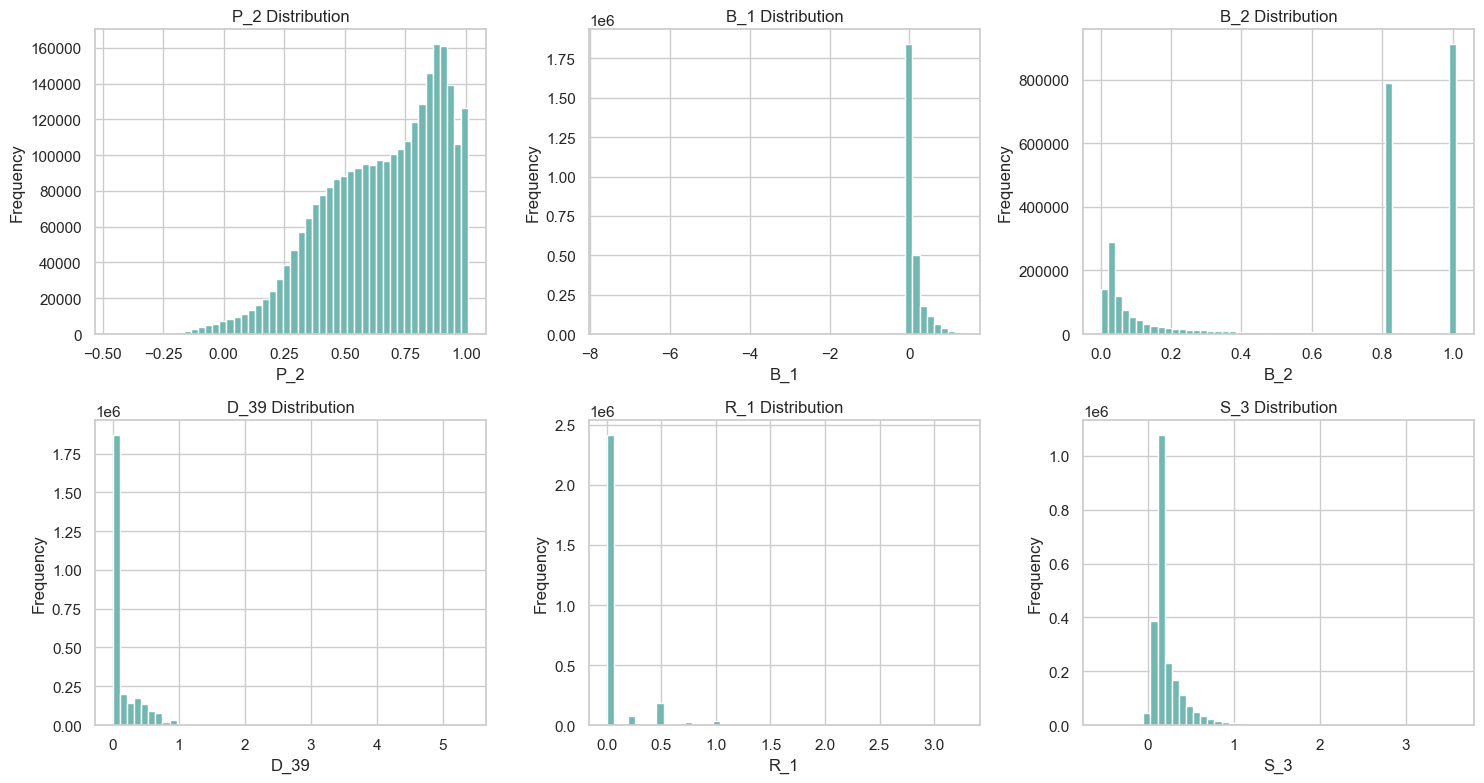

In [57]:
key_numeric_cols = [col for col in ['P_2', 'B_1', 'B_2', 'D_39', 'R_1', 'S_3'] if col in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, key_numeric_cols):
    df[col].plot(kind='hist', bins=50, ax=ax, color='#72B7B2', edgecolor='white')
    ax.set_title(f'{col} Distribution')
    ax.set_xlabel(col)

for ax in axes[len(key_numeric_cols):]:
    ax.axis('off')

plt.tight_layout()
plt.show()


/var/folders/z6/3r0k6xhs10q6g53dzsc3ppxr0000gn/T/ipykernel_9898/774715647.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=last_df, x='target', y=col, ax=ax, palette=['#4C78A8', '#F58518'])
/var/folders/z6/3r0k6xhs10q6g53dzsc3ppxr0000gn/T/ipykernel_9898/774715647.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=last_df, x='target', y=col, ax=ax, palette=['#4C78A8', '#F58518'])
/var/folders/z6/3r0k6xhs10q6g53dzsc3ppxr0000gn/T/ipykernel_9898/774715647.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=last_df, x='target',

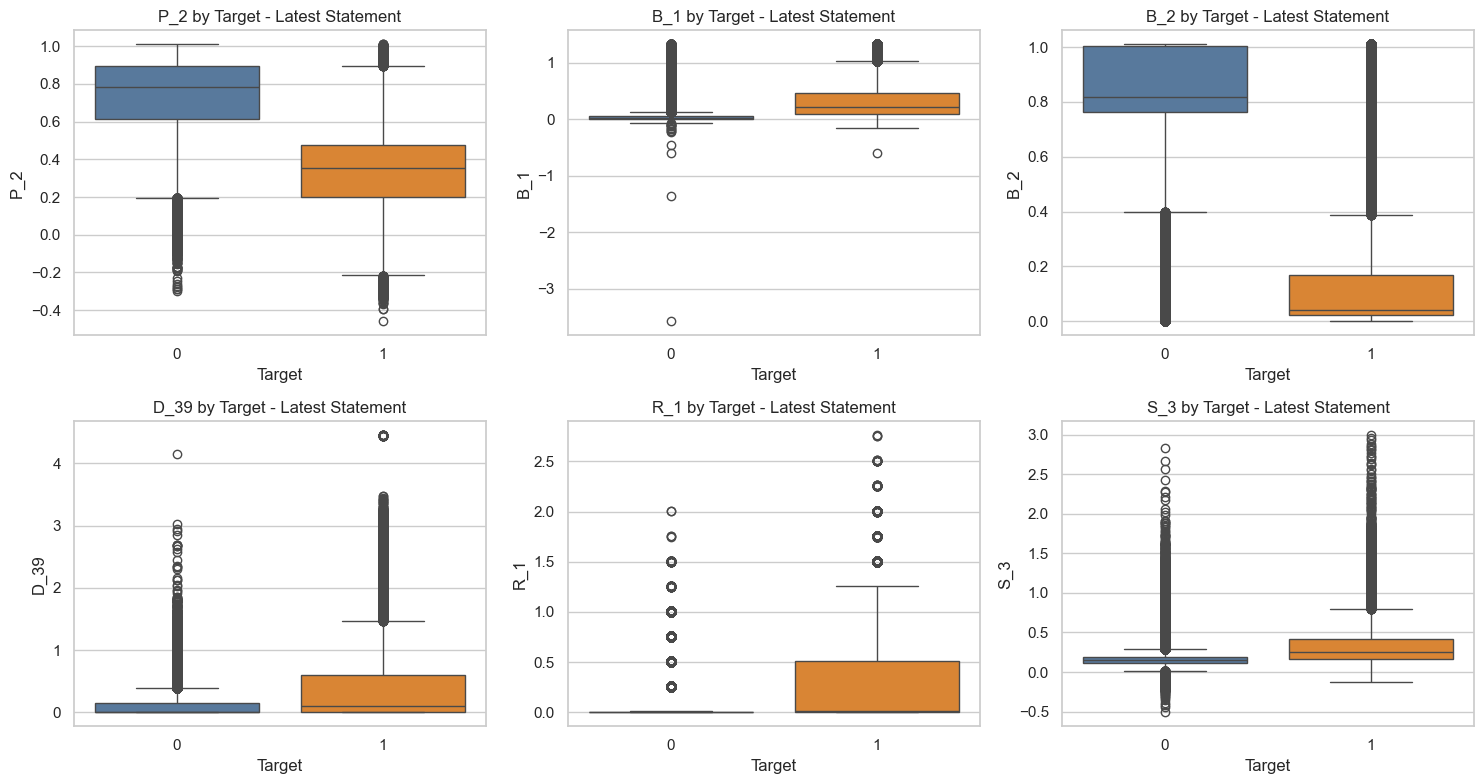

In [58]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, key_numeric_cols):
    sns.boxplot(data=last_df, x='target', y=col, ax=ax, palette=['#4C78A8', '#F58518'])
    ax.set_title(f'{col} by Target - Latest Statement')
    ax.set_xlabel('Target')

for ax in axes[len(key_numeric_cols):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

### Numerical Feature Observations

- Several numerical variables exhibit right-skewed distributions and contain outliers.
- No transformations or outlier removal were applied because LightGBM and XGBoost are tree-based models that are robust to skewed distributions and extreme values.
- These numerical features are aggregated into customer-level statistics during feature engineering.

## Final Checks and Save


In [60]:
df.duplicated().sum()

0

In [61]:
df = df.sort_values(['customer_ID', 'S_2'])

In [62]:
df.to_parquet('../data/processed/train_preprocessed.parquet', index=False)
print("Saved!")

Saved!
